# `solaqua_fish` — Dataset Statistics

Visual summary of the `split_yolo` processed split: class balance, scale variance, objects-per-image distribution, and instance placement heatmaps.

**Class:** `0 = fish`  
**Image size:** 1280 × 720 px  
**Splits:** train / val / test (bag-disjoint)

In [1]:
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm

# ── paths ────────────────────────────────────────────────────────────────────
SPLIT_YOLO = Path("processed/split_yolo")
IMG_W, IMG_H = 1280, 720
SPLITS = ["train", "val", "test"]
FISH_COLOR   = "#E84855"
SPLIT_COLORS = {"train": "#2E86AB", "val": "#F18F01", "test": "#A23B72"}

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── load all YOLO label files ────────────────────────────────────────────────
records = []
img_records = []

for split in SPLITS:
    lbl_dir = SPLIT_YOLO / "labels" / split
    for lbl_path in sorted(lbl_dir.glob("*.txt")):
        text  = lbl_path.read_text(encoding="utf-8").strip()
        lines = [l for l in text.splitlines() if l.strip()]

        # extract bag id from filename (e.g. 00d3710d-bag1_... → bag1)
        m = re.search(r"-(bag\d+)_", lbl_path.stem)
        bag_id = m.group(1) if m else "unknown"

        n_fish = 0
        for line in lines:
            parts = line.split()
            cls = int(parts[0])   # always 0 (fish) in this dataset
            xc, yc, wn, hn = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            records.append({
                "split":     split,
                "bag":       bag_id,
                "image":     lbl_path.stem,
                "xc":        xc,
                "yc":        yc,
                "wn":        wn,
                "hn":        hn,
                "area_norm": wn * hn,
                "w_px":      wn * IMG_W,
                "h_px":      hn * IMG_H,
                "area_px":   wn * hn * IMG_W * IMG_H,
            })
            n_fish += 1

        img_records.append({
            "split":  split,
            "bag":    bag_id,
            "image":  lbl_path.stem,
            "n_fish": n_fish,
        })

df     = pd.DataFrame(records)
df_img = pd.DataFrame(img_records)

print(f"Instances loaded : {len(df):,}")
print(f"Images loaded    : {len(df_img):,}")
print(df_img.groupby("split")[["n_fish"]].agg(["count", "sum", "mean"]).round(2))

Instances loaded : 3,153
Images loaded    : 793
      n_fish            
       count   sum  mean
split                   
test     164   587  3.58
train    505  2101  4.16
val      124   465  3.75


## 1 — Dataset overview

,Images,Background images,Fish instances,Min fish/img,Max fish/img,Mean fish/img,Median fish/img
Split,,,,,,,
train,505,38,2101,0,24,4.16,2.0
val,124,10,465,0,17,3.75,3.0
test,164,11,587,0,28,3.58,2.0
TOTAL,793,59,3153,0,28,3.98,2.0


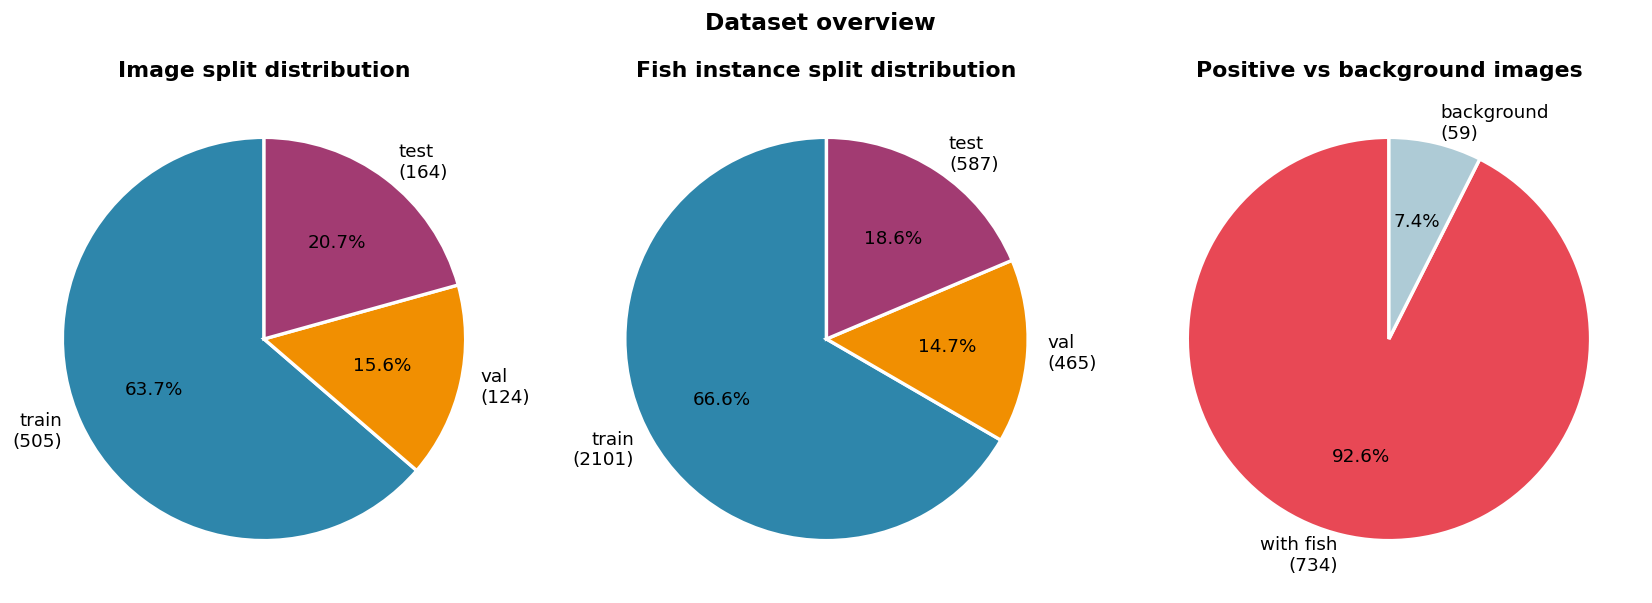

In [2]:
# ── summary table ────────────────────────────────────────────────────────────
rows = []
for split in SPLITS:
    imgs = df_img[df_img["split"] == split]
    inst = df[df["split"] == split]
    rows.append({
        "Split":              split,
        "Images":             len(imgs),
        "Background images":  int((imgs["n_fish"] == 0).sum()),
        "Fish instances":     len(inst),
        "Min fish/img":       int(imgs["n_fish"].min()),
        "Max fish/img":       int(imgs["n_fish"].max()),
        "Mean fish/img":      round(imgs["n_fish"].mean(), 2),
        "Median fish/img":    round(imgs["n_fish"].median(), 1),
    })
totals = {
    "Split":              "TOTAL",
    "Images":             len(df_img),
    "Background images":  int((df_img["n_fish"] == 0).sum()),
    "Fish instances":     len(df),
    "Min fish/img":       int(df_img["n_fish"].min()),
    "Max fish/img":       int(df_img["n_fish"].max()),
    "Mean fish/img":      round(df_img["n_fish"].mean(), 2),
    "Median fish/img":    round(df_img["n_fish"].median(), 1),
}
rows.append(totals)
display(pd.DataFrame(rows).set_index("Split"))

# ── pie charts ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# (a) image split distribution
split_counts = df_img.groupby("split").size().reindex(SPLITS)
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    split_counts.values,
    labels=[f"{s}\n({v})".replace("(", "(") for s, v in zip(SPLITS, split_counts.values)],
    colors=[SPLIT_COLORS[s] for s in SPLITS],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts: at.set_fontsize(11)
ax.set_title("Image split distribution", fontweight="bold")

# (b) fish instances per split
inst_counts = df.groupby("split").size().reindex(SPLITS)
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    inst_counts.values,
    labels=[f"{s}\n({v})" for s, v in zip(SPLITS, inst_counts.values)],
    colors=[SPLIT_COLORS[s] for s in SPLITS],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts: at.set_fontsize(11)
ax.set_title("Fish instance split distribution", fontweight="bold")

# (c) positive vs background images
n_pos = int((df_img["n_fish"] > 0).sum())
n_bg  = int((df_img["n_fish"] == 0).sum())
ax = axes[2]
wedges, texts, autotexts = ax.pie(
    [n_pos, n_bg],
    labels=[f"with fish\n({n_pos})", f"background\n({n_bg})"],
    colors=[FISH_COLOR, "#AECBD6"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts: at.set_fontsize(11)
ax.set_title("Positive vs background images", fontweight="bold")

plt.suptitle("Dataset overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 2 — Objects per image

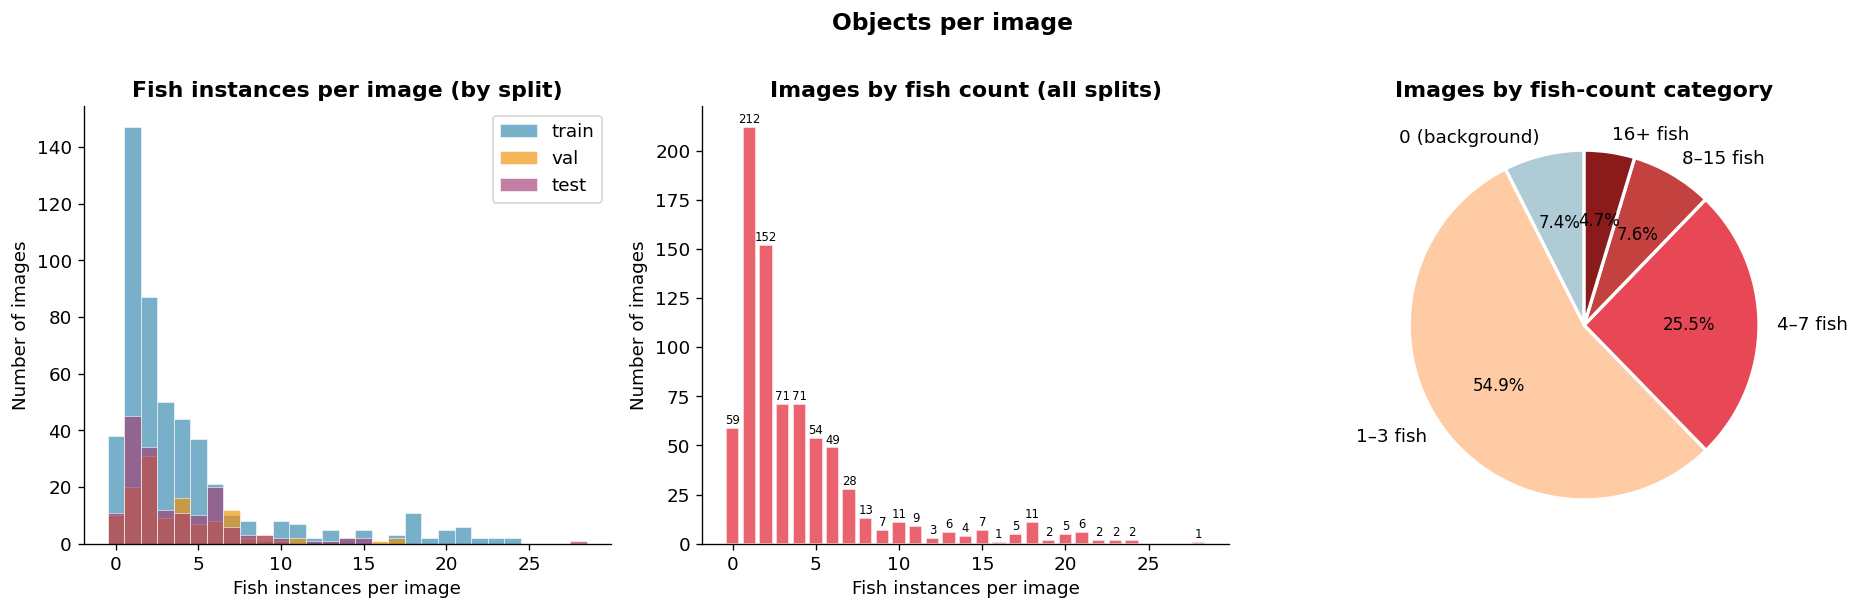

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (a) histogram per split ──────────────────────────────────────────────────
ax = axes[0]
max_fish = df_img["n_fish"].max()
bins = np.arange(0, max_fish + 2) - 0.5
for split in SPLITS:
    vals = df_img[df_img["split"] == split]["n_fish"]
    ax.hist(vals, bins=bins, alpha=0.65, label=split,
            color=SPLIT_COLORS[split], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Fish instances per image")
ax.set_ylabel("Number of images")
ax.set_title("Fish instances per image (by split)", fontweight="bold")
ax.legend()

# ── (b) bar chart — all splits combined ─────────────────────────────────────
ax = axes[1]
fish_freq = df_img["n_fish"].value_counts().sort_index()
ax.bar(fish_freq.index, fish_freq.values, color=FISH_COLOR, edgecolor="white", alpha=0.85)
ax.set_xlabel("Fish instances per image")
ax.set_ylabel("Number of images")
ax.set_title("Images by fish count (all splits)", fontweight="bold")
for x, v in zip(fish_freq.index, fish_freq.values):
    if v > 0:
        ax.text(x, v + 0.5, str(v), ha="center", va="bottom", fontsize=7)

# ── (c) pie — category buckets ───────────────────────────────────────────────
ax = axes[2]

def fish_cat(n):
    if n == 0:          return "0 (background)"
    if 1 <= n <= 3:     return "1–3 fish"
    if 4 <= n <= 7:     return "4–7 fish"
    if 8 <= n <= 15:    return "8–15 fish"
    return "16+ fish"

cat_order  = ["0 (background)", "1–3 fish", "4–7 fish", "8–15 fish", "16+ fish"]
cat_colors = ["#AECBD6", "#FFCBA4", FISH_COLOR, "#C3423F", "#8B1A1A"]

df_img["fish_cat"] = df_img["n_fish"].apply(fish_cat)
cat_counts = df_img["fish_cat"].value_counts().reindex(cat_order, fill_value=0)
mask = cat_counts > 0
wedges, texts, autotexts = ax.pie(
    cat_counts[mask].values,
    labels=cat_counts[mask].index.tolist(),
    colors=[c for c, m in zip(cat_colors, mask) if m],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts: at.set_fontsize(10)
ax.set_title("Images by fish-count category", fontweight="bold")

plt.suptitle("Objects per image", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3 — Scale variance (bounding box sizes)

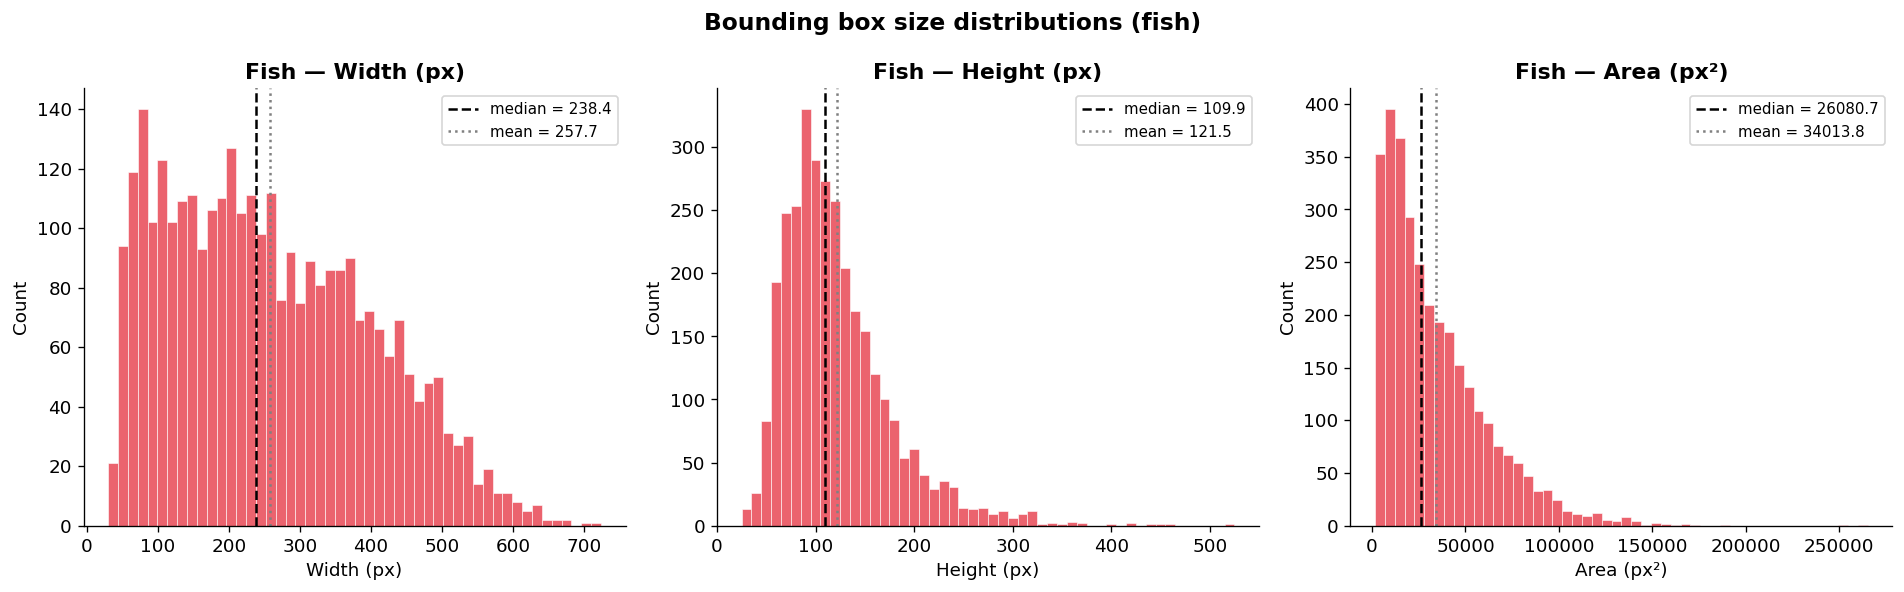

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (key, label) in zip(axes, [
    ("w_px",    "Width (px)"),
    ("h_px",    "Height (px)"),
    ("area_px", "Area (px²)"),
]):
    vals = df[key]
    ax.hist(vals, bins=50, color=FISH_COLOR, alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.axvline(vals.median(), color="black", linestyle="--", linewidth=1.5,
               label=f"median = {vals.median():.1f}")
    ax.axvline(vals.mean(),   color="gray",  linestyle=":",  linewidth=1.5,
               label=f"mean = {vals.mean():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Fish — {label}", fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Bounding box size distributions (fish)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

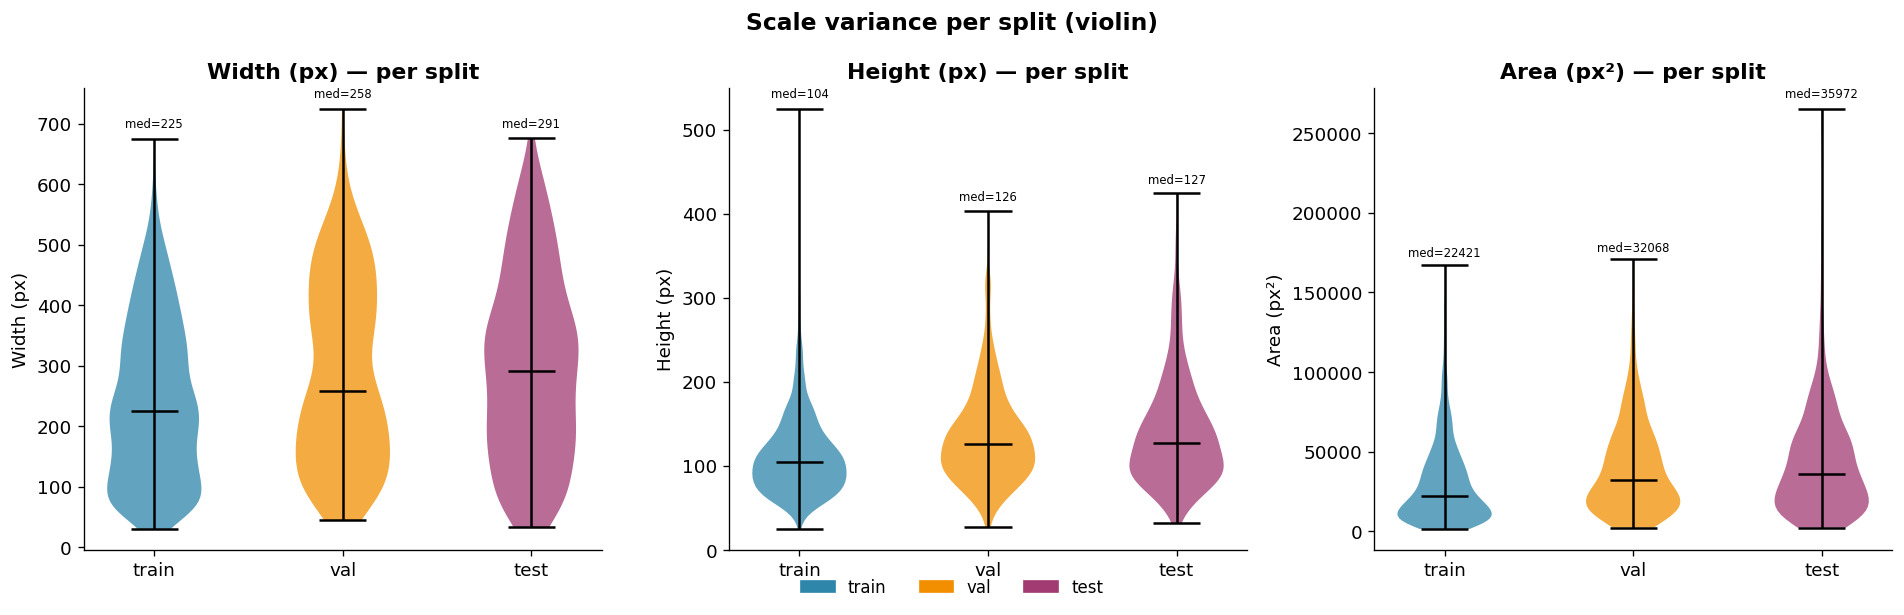

In [5]:
# ── per-split violin plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (key, label) in zip(axes, [
    ("w_px",    "Width (px)"),
    ("h_px",    "Height (px)"),
    ("area_px", "Area (px²)"),
]):
    split_data = [df[df["split"] == s][key].values for s in SPLITS]
    parts = ax.violinplot(
        split_data, positions=range(len(SPLITS)),
        showmedians=True, showextrema=True,
    )
    for pc, split in zip(parts["bodies"], SPLITS):
        pc.set_facecolor(SPLIT_COLORS[split])
        pc.set_alpha(0.75)
    for k in ["cmedians", "cbars", "cmins", "cmaxes"]:
        parts[k].set_color("black")

    ax.set_xticks(range(len(SPLITS)))
    ax.set_xticklabels(SPLITS)
    ax.set_ylabel(label)
    ax.set_title(f"{label} — per split", fontweight="bold")

    for pos, vals in enumerate(split_data):
        ax.text(pos, np.max(vals) * 1.02,
                f"med={np.median(vals):.0f}",
                ha="center", va="bottom", fontsize=7)

legend_patches = [mpatches.Patch(color=SPLIT_COLORS[s], label=s) for s in SPLITS]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Scale variance per split (violin)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

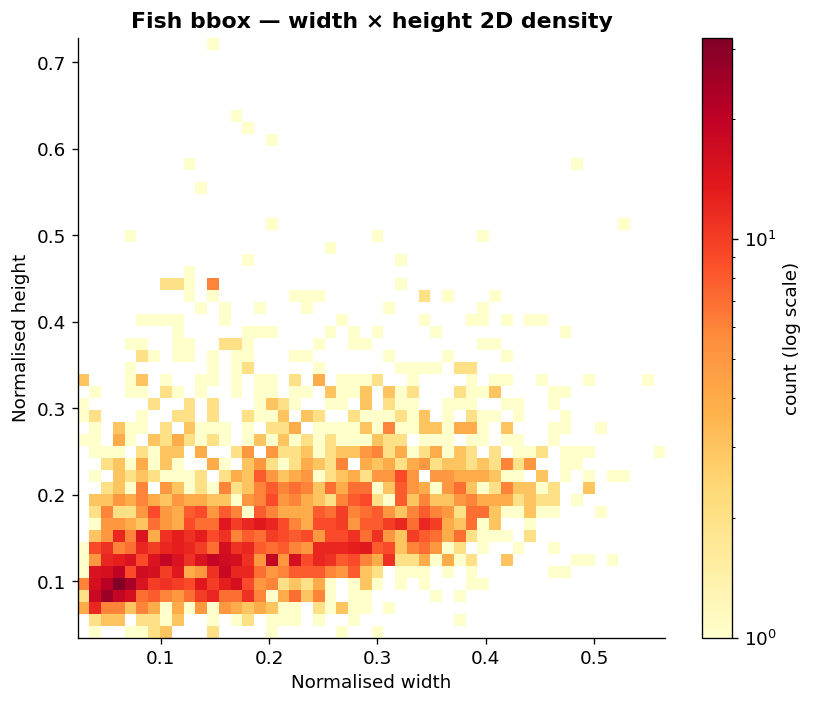

In [6]:
# ── 2D density: bbox width × height ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(
    df["wn"], df["hn"],
    bins=50,
    norm=LogNorm(),
    cmap="YlOrRd",
)
plt.colorbar(h[3], ax=ax, label="count (log scale)")
ax.set_xlabel("Normalised width")
ax.set_ylabel("Normalised height")
ax.set_title("Fish bbox — width × height 2D density", fontweight="bold")
plt.tight_layout()
plt.show()

## 4 — Instance placement heatmaps

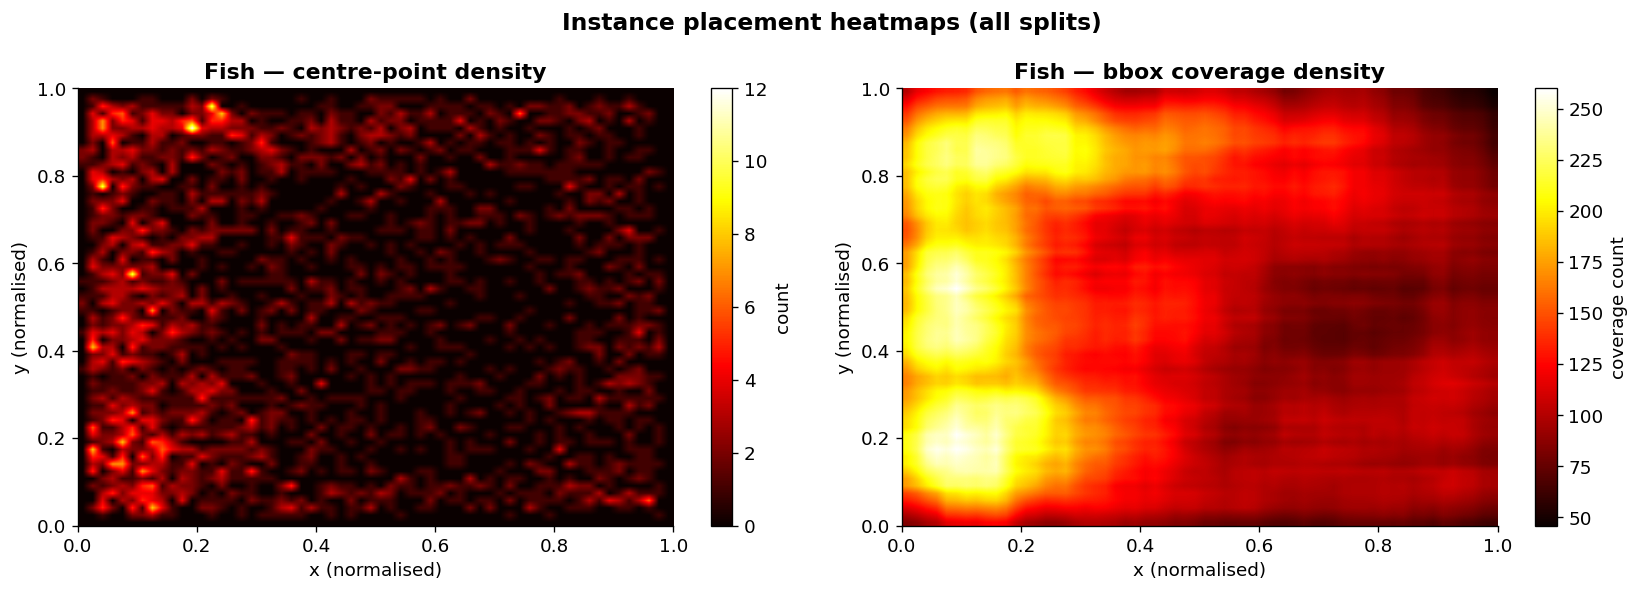

In [7]:
GRID = 60

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── centre-point density (all splits) ────────────────────────────────────────
ax = axes[0]
h, _, _ = np.histogram2d(df["xc"], df["yc"], bins=GRID, range=[[0, 1], [0, 1]])
im = ax.imshow(
    h.T, origin="upper", extent=[0, 1, 1, 0],
    aspect="auto", cmap="hot", interpolation="bilinear",
)
plt.colorbar(im, ax=ax, label="count")
ax.set_xlabel("x (normalised)")
ax.set_ylabel("y (normalised)")
ax.set_title("Fish — centre-point density", fontweight="bold")
ax.invert_yaxis()

# ── bbox coverage density ─────────────────────────────────────────────────────
ax = axes[1]
coverage = np.zeros((GRID, GRID), dtype=np.float32)
xs = np.linspace(0, 1, GRID + 1)
ys = np.linspace(0, 1, GRID + 1)

for _, r in df.iterrows():
    x1, x2 = r["xc"] - r["wn"] / 2, r["xc"] + r["wn"] / 2
    y1, y2 = r["yc"] - r["hn"] / 2, r["yc"] + r["hn"] / 2
    xi1 = max(0, np.searchsorted(xs, x1) - 1)
    xi2 = min(GRID, np.searchsorted(xs, x2))
    yi1 = max(0, np.searchsorted(ys, y1) - 1)
    yi2 = min(GRID, np.searchsorted(ys, y2))
    coverage[xi1:xi2, yi1:yi2] += 1

im2 = ax.imshow(
    coverage.T, origin="upper", extent=[0, 1, 1, 0],
    aspect="auto", cmap="hot", interpolation="bilinear",
)
plt.colorbar(im2, ax=ax, label="coverage count")
ax.set_xlabel("x (normalised)")
ax.set_ylabel("y (normalised)")
ax.set_title("Fish — bbox coverage density", fontweight="bold")
ax.invert_yaxis()

plt.suptitle("Instance placement heatmaps (all splits)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

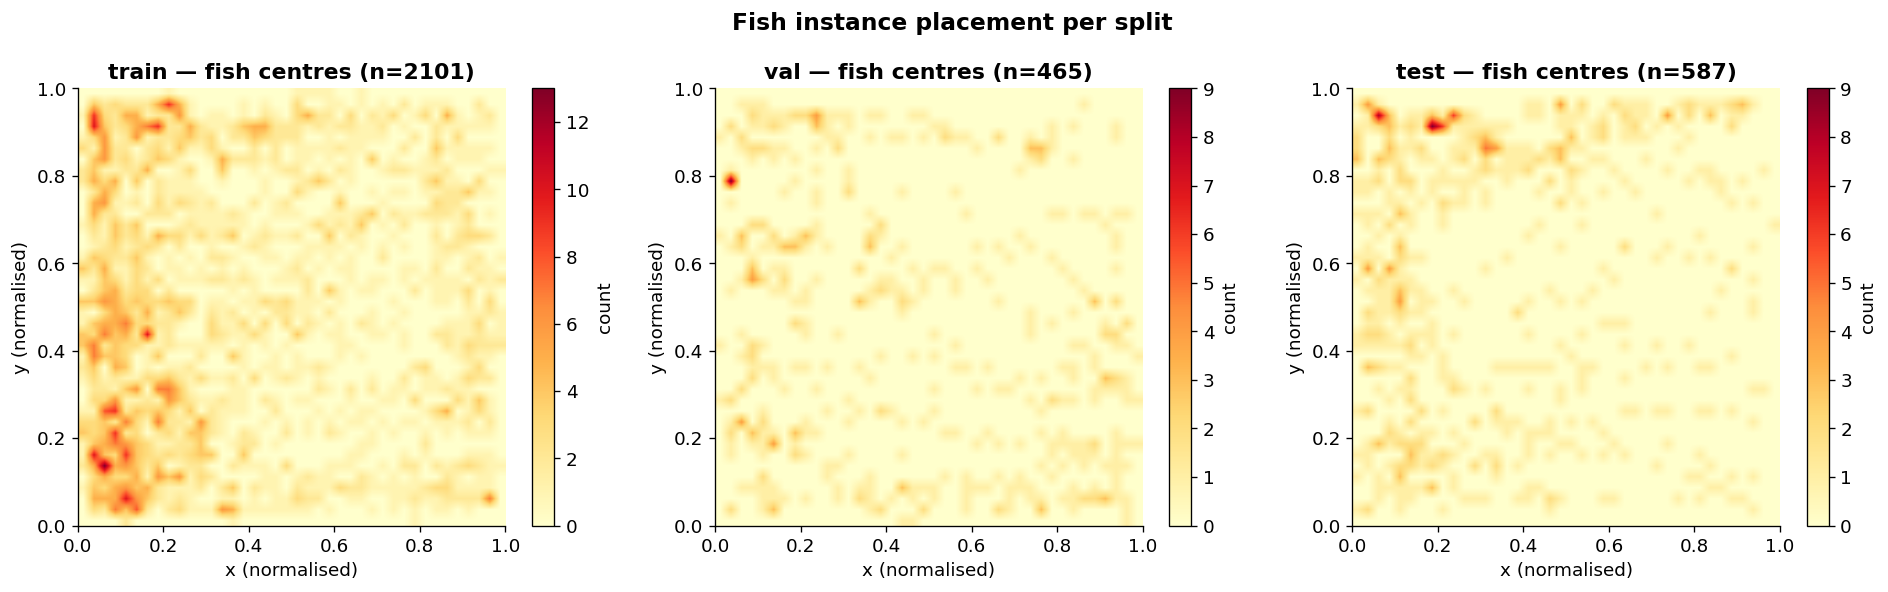

In [8]:
# ── centre-point placement per split ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, split in zip(axes, SPLITS):
    sub = df[df["split"] == split]
    h, _, _ = np.histogram2d(sub["xc"], sub["yc"], bins=40, range=[[0, 1], [0, 1]])
    im = ax.imshow(
        h.T, origin="upper", extent=[0, 1, 1, 0],
        aspect="auto", cmap="YlOrRd", interpolation="bilinear",
    )
    plt.colorbar(im, ax=ax, label="count")
    ax.set_xlabel("x (normalised)")
    ax.set_ylabel("y (normalised)")
    ax.invert_yaxis()
    ax.set_title(f"{split} — fish centres (n={len(sub)})", fontweight="bold")

plt.suptitle("Fish instance placement per split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5 — Per-bag breakdown

,images,fish_instances,positive_images,background_imgs,split,avg_fish_per_img,background_rate
bag,,,,,,,
bag1,72,222,71,1,train,3.08,0.014
bag2,76,246,71,5,val,3.24,0.066
bag3,19,29,17,2,test,1.53,0.105
bag4,75,955,75,0,train,12.73,0.000
bag8,32,25,23,9,train,0.78,0.281
bag9,16,62,16,0,train,3.88,0.000
bag10,48,219,43,5,val,4.56,0.104
bag11,35,159,34,1,test,4.54,0.029
bag12,90,292,79,11,train,3.24,0.122


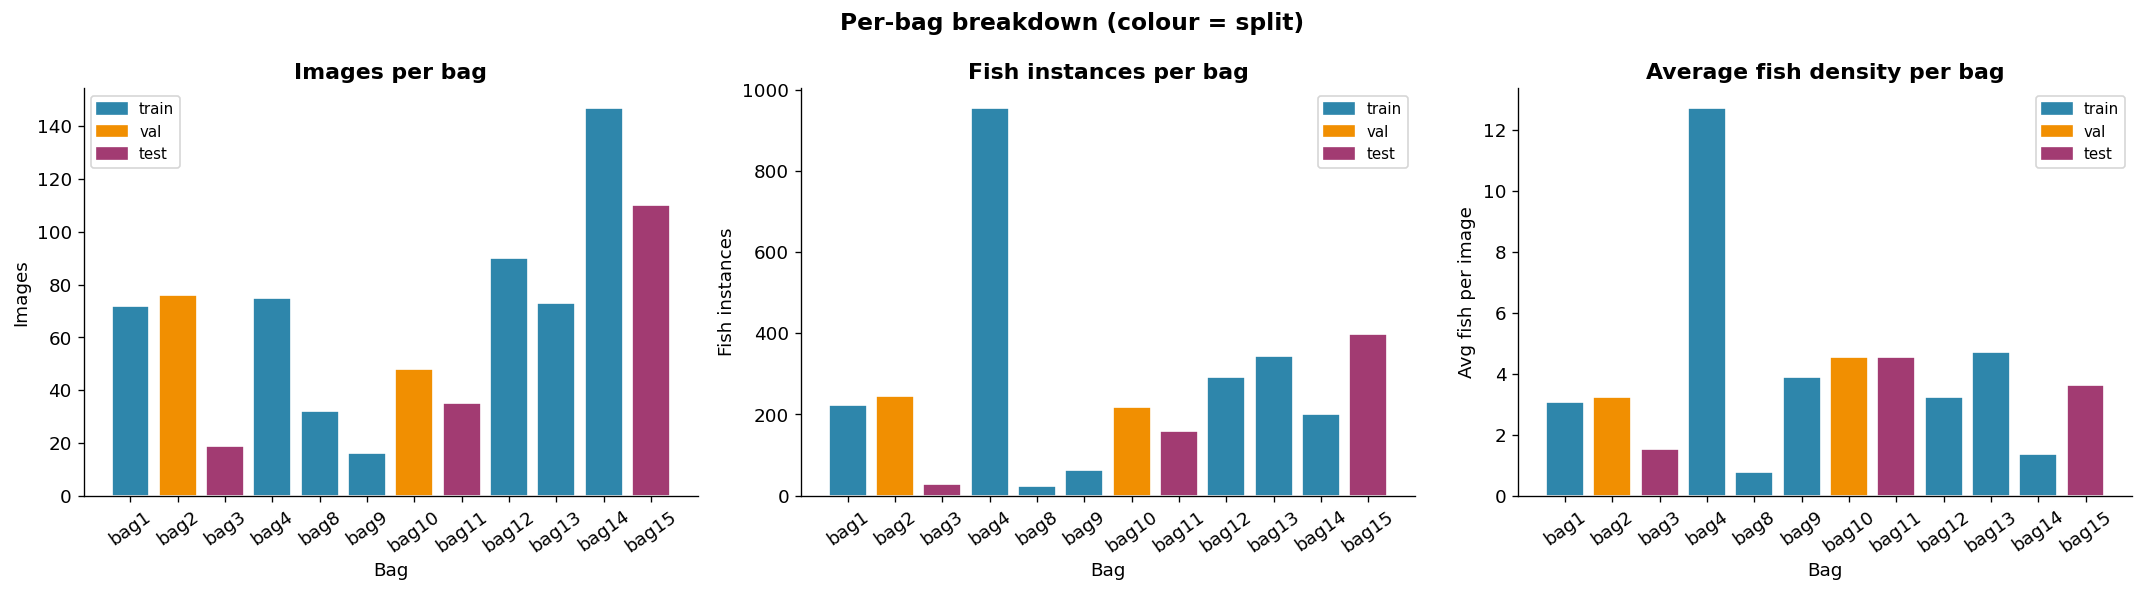

In [9]:
bag_order = sorted(
    df_img["bag"].unique(),
    key=lambda s: int(re.search(r"\d+", s).group())
)

bag_stats = (
    df_img.groupby("bag")
    .agg(
        images          =("image",   "count"),
        fish_instances  =("n_fish",  "sum"),
        positive_images =("n_fish",  lambda x: (x > 0).sum()),
        background_imgs =("n_fish",  lambda x: (x == 0).sum()),
        split           =("split",   "first"),
    )
    .reindex(bag_order)
    .reset_index()
)
bag_stats["avg_fish_per_img"]  = (bag_stats["fish_instances"] / bag_stats["images"]).round(2)
bag_stats["background_rate"]   = (bag_stats["background_imgs"] / bag_stats["images"]).round(3)
display(bag_stats.set_index("bag"))

# ── bar charts ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = [SPLIT_COLORS[row.split] for row in bag_stats.itertuples()]
legend_patches = [mpatches.Patch(color=SPLIT_COLORS[s], label=s) for s in SPLITS]

ax = axes[0]
ax.bar(bag_stats["bag"], bag_stats["images"], color=bar_colors, edgecolor="white")
ax.set_xlabel("Bag")
ax.set_ylabel("Images")
ax.set_title("Images per bag", fontweight="bold")
ax.tick_params(axis="x", rotation=35)
ax.legend(handles=legend_patches, fontsize=9)

ax = axes[1]
ax.bar(bag_stats["bag"], bag_stats["fish_instances"], color=bar_colors, edgecolor="white")
ax.set_xlabel("Bag")
ax.set_ylabel("Fish instances")
ax.set_title("Fish instances per bag", fontweight="bold")
ax.tick_params(axis="x", rotation=35)
ax.legend(handles=legend_patches, fontsize=9)

ax = axes[2]
ax.bar(bag_stats["bag"], bag_stats["avg_fish_per_img"], color=bar_colors, edgecolor="white")
ax.set_xlabel("Bag")
ax.set_ylabel("Avg fish per image")
ax.set_title("Average fish density per bag", fontweight="bold")
ax.tick_params(axis="x", rotation=35)
ax.legend(handles=legend_patches, fontsize=9)

plt.suptitle("Per-bag breakdown (colour = split)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 — Numeric summary

In [10]:
print("=== Fish bbox statistics (all splits) ===")
display(df[["w_px", "h_px", "area_px", "area_norm"]].describe().round(2))

print("\n=== Fish instances per image ===")
display(df_img["n_fish"].describe().round(2))

print("\n=== Fish instances per image (positive images only) ===")
display(df_img[df_img["n_fish"] > 0]["n_fish"].describe().round(2))

=== Fish bbox statistics (all splits) ===


,w_px,h_px,area_px,area_norm
count,3153.00,3153.00,3153.00,3153.00
mean,257.74,121.45,34013.83,0.04
std,141.67,55.00,28015.50,0.03
min,29.98,24.95,1599.15,0.00
25%,138.97,83.86,12839.41,0.01
50%,238.40,109.89,26080.67,0.03
75%,363.00,145.67,48114.05,0.05
max,724.13,524.73,265209.95,0.29



=== Fish instances per image ===


count    793.00
mean       3.98
std        4.57
min        0.00
25%        1.00
50%        2.00
75%        5.00
max       28.00
Name: n_fish, dtype: float64


=== Fish instances per image (positive images only) ===


count    734.0
mean       4.3
std        4.6
min        1.0
25%        1.0
50%        3.0
75%        5.0
max       28.0
Name: n_fish, dtype: float64